<a href="https://colab.research.google.com/github/dettystanly7676/Python_Practice_Repo/blob/main/Supervised_Learning_CaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Introduction

In [131]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier # for k-NN
from sklearn.linear_model import LogisticRegression # for logarithmic regression
from sklearn.naive_bayes import GaussianNB # for naive baye's
from sklearn.tree import DecisionTreeClassifier # fro decision tree
from sklearn.svm import SVC #SVM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [132]:
trainig_data_path = '/content/drive/MyDrive/DSA_ICT/Data/Training_data.csv'
training_data = pd.read_csv(trainig_data_path)

#1. Exploratory Data Analysis

In [133]:
training_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [134]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [135]:
training_data.size

118314

In [136]:
training_data.shape

(5634, 21)

In [137]:
training_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [138]:
training_data.nunique()

,0
customerID,5634
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [139]:
training_data['OnlineSecurity'].unique()

array(['No internet service', 'No', nan, 'Yes'], dtype=object)

# 2. Data Preprocessing

In [140]:
training_data.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [141]:
training_data.drop(columns=['gender'], inplace=True)

In [142]:
training_data.drop(columns=['PaperlessBilling'], inplace=True)

In [143]:
training_data.isna().sum()

,0
customerID,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169
OnlineBackup,0


In [144]:
training_data.head()

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,0,No,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Mailed check,20.75,700.45,No
1,7746-AWNQW,0,No,No,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Mailed check,35.75,961.4,No
2,2208-UGTGR,0,No,No,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,0,Yes,No,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,0,Yes,Yes,43,No,No phone service,DSL,NaN,Yes,No,Yes,Yes,No,One year,Bank transfer (automatic),51.25,2151.6,No


In [145]:
training_data['PhoneService'].unique()

array(['Yes', 'No'], dtype=object)

In [146]:
training_data.drop(columns=['customerID'], inplace=True)

In [147]:
training_data.drop(columns=['PaymentMethod'], inplace=True)

In [148]:
training_data.drop(columns=['SeniorCitizen'], inplace=True)

In [149]:
training_data.drop(columns=['Partner'], inplace=True)

In [150]:
training_data.drop(columns=['Dependents'], inplace=True)

In [151]:
training_data.head()

,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,MonthlyCharges,TotalCharges,Churn
0,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,20.75,700.45,No
1,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,35.75,961.4,No
2,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,98.60,5581.05,No
3,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,20.45,790,No
4,43,No,No phone service,DSL,NaN,Yes,No,Yes,Yes,No,One year,51.25,2151.6,No


Churn           No   Yes
PhoneService            
No             416   137
Yes           3714  1367


<Axes: xlabel='PhoneService'>

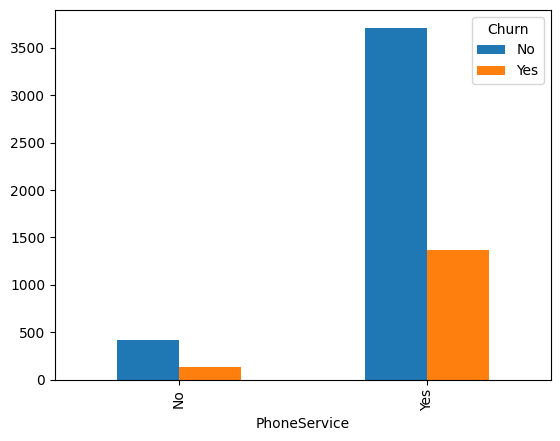

In [152]:
table = pd.crosstab(training_data['PhoneService'], training_data['Churn'])
print(table)
table.plot(kind='bar')

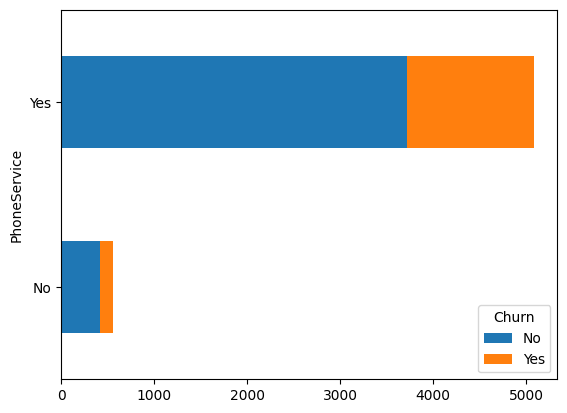

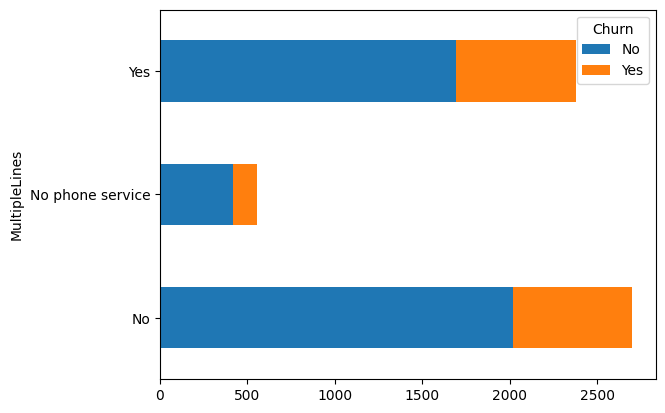

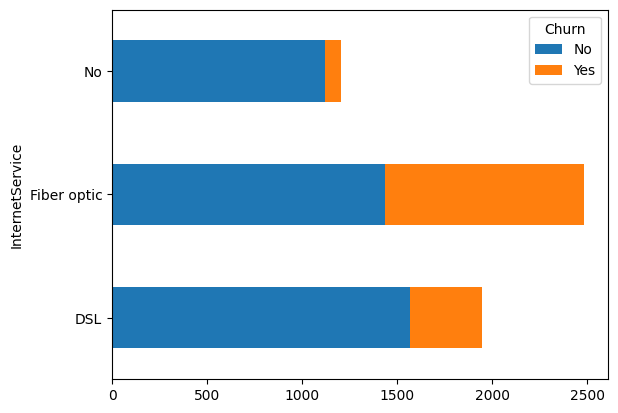

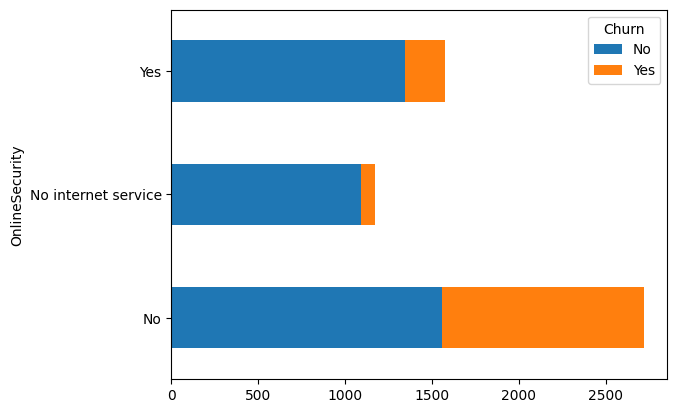

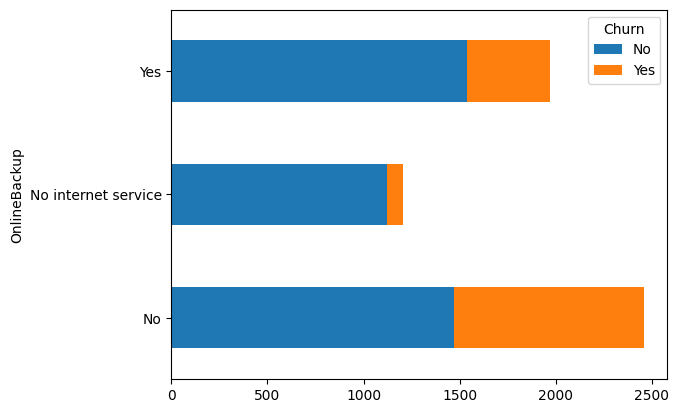

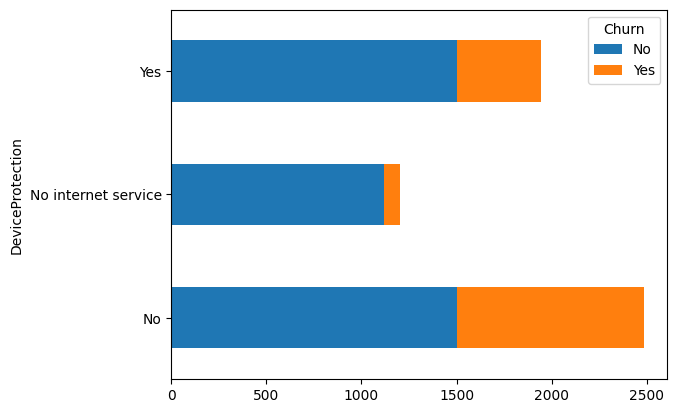

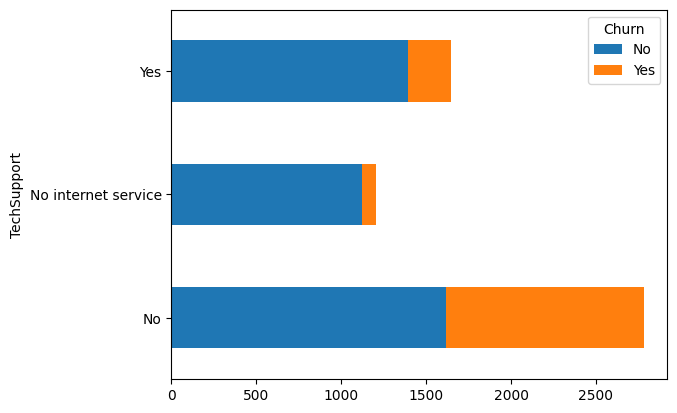

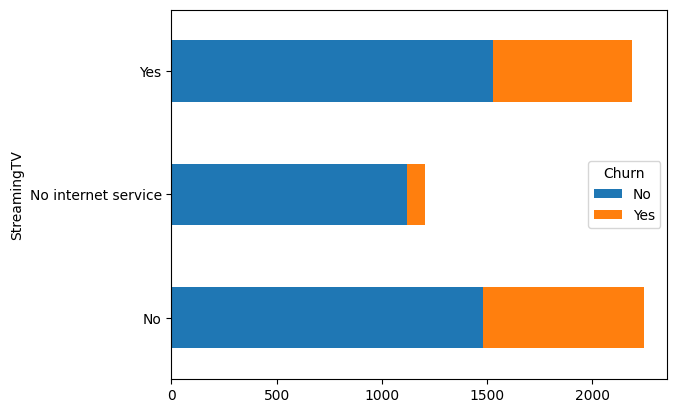

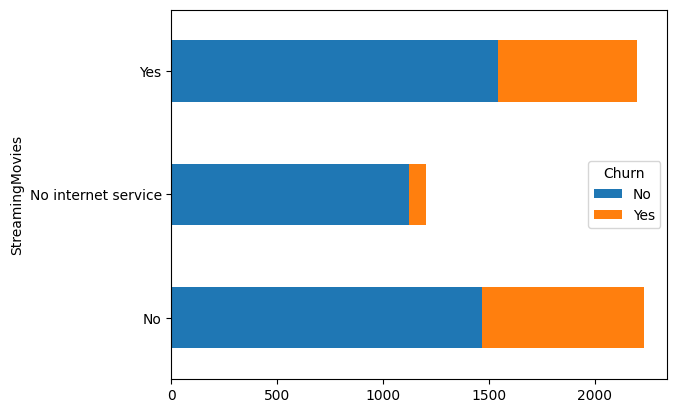

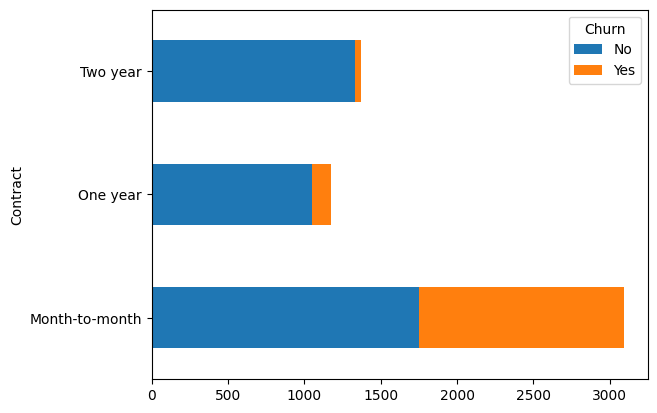

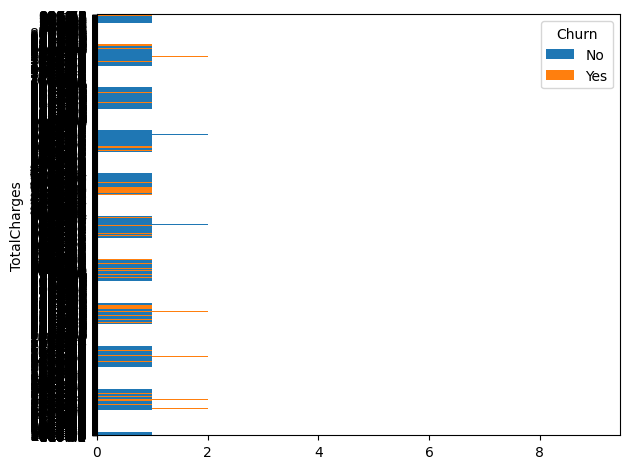

In [153]:
category_columns = training_data.select_dtypes(include='object').columns.drop('Churn')

for col in category_columns:
  table = pd.crosstab(training_data[col],training_data['Churn'])
  table.plot(kind='barh', stacked=True)

plt.tight_layout()
plt.show()

From above each graphs plotted, each feature relation with the target is

clearly understood. This helps in better data analysis.

In [154]:
training_data.head()

,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,MonthlyCharges,TotalCharges,Churn
0,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,20.75,700.45,No
1,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,35.75,961.4,No
2,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,98.60,5581.05,No
3,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,20.45,790,No
4,43,No,No phone service,DSL,NaN,Yes,No,Yes,Yes,No,One year,51.25,2151.6,No


In [155]:
training_data.isnull().sum()

,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169
OnlineBackup,0
DeviceProtection,0
TechSupport,0
StreamingTV,0
StreamingMovies,0


In [156]:
set_mode = training_data['OnlineSecurity'].mode()[0]
set_mode
training_data['OnlineSecurity'].fillna(set_mode,inplace=True)

/tmp/ipython-input-3224720550.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  training_data['OnlineSecurity'].fillna(set_mode,inplace=True)


In [157]:
# TotalCharges column is stored as strings (object), not numeric.
# So Pandas can’t calculate median() on it.

# converting it to numeric first, then fill missing values.

training_data['TotalCharges'] = pd.to_numeric(training_data['TotalCharges'], errors='coerce')
training_data['TotalCharges'] = training_data['TotalCharges'].fillna(training_data['TotalCharges'].median())

In [158]:
# TotalCharges column is stored as strings (object), not numeric.
# So Pandas can’t calculate median() on it.

# converting it to numeric first, then fill missing values.
training_data['MonthlyCharges'] = training_data['MonthlyCharges'].fillna(training_data['MonthlyCharges'].median())

In [159]:
training_data.isna().sum()

,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0
TechSupport,0
StreamingTV,0
StreamingMovies,0


<Axes: >

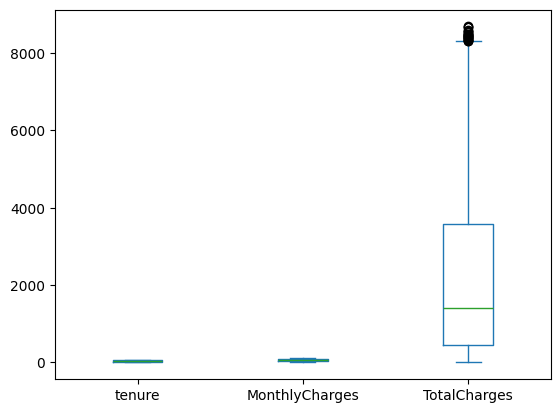

In [160]:
training_data.plot(kind = 'box')

Outlier is clearly visible. Handling them below using IQR method

In [161]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = training_data['TotalCharges'].quantile(0.25)
Q3 = training_data['TotalCharges'].quantile(0.75)

# Calculate the IQR
IQR = Q3 - Q1

# Define the bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

# Identify the outliers
outliers = training_data[(training_data['TotalCharges'] < lower_bound) | (training_data['TotalCharges'] > upper_bound)]
print(f"Total outliers found: {len(outliers)}")

Lower Bound: -4270.65
Upper Bound: 8307.25
Total outliers found: 24


In [162]:
training_data['TotalCharges'] = training_data['TotalCharges'].clip(lower=lower_bound,upper=upper_bound)

<Axes: >

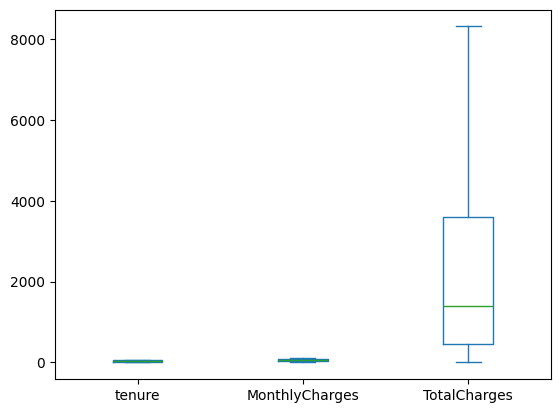

In [163]:
training_data.plot(kind = 'box')

In [164]:
training_data.head()

,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,MonthlyCharges,TotalCharges,Churn
0,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,20.75,700.45,No
1,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,35.75,961.40,No
2,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,98.60,5581.05,No
3,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,20.45,790.00,No
4,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,51.25,2151.60,No


# 3. Feature Engineering

In [165]:
# new feature implementing to improve model performance customer lifetime value (Tenure * MonthlyCharges)?
training_data['Customer_Lifetime_Value'] =training_data['tenure'] * training_data['MonthlyCharges']

In [168]:
# new feature implementing to improve model performanc Tenure Contract Interaction (Tenure * Contract)?
# Month-to-month: 1, One year: 12, Two year: 24
training_data['Contract'] = training_data['Contract'].map({'Month-to-month': 1, 'One year': 12, 'Two year': 24})

# Interaction Feature
training_data['Tenure_Contract_Interaction'] = training_data['tenure'] * training_data['Contract_Data']

In [171]:
training_data.head()

,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,MonthlyCharges,TotalCharges,Churn,Customer_Lifetime_Value,Tenure_Contract_Interaction
0,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,12,20.75,700.45,No,726.25,420
1,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,1,35.75,961.40,No,1001.00,28
2,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,1,98.60,5581.05,No,5521.60,56
3,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,24,20.45,790.00,No,797.55,936
4,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,12,51.25,2151.60,No,2203.75,516


In [172]:
leEncoder = LabelEncoder()
training_data['PhoneService'] = leEncoder.fit_transform(training_data['PhoneService'])

In [173]:
training_data.head()

,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,MonthlyCharges,TotalCharges,Churn,Customer_Lifetime_Value,Tenure_Contract_Interaction
0,35,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,12,20.75,700.45,No,726.25,420
1,28,0,No phone service,DSL,No,No,Yes,Yes,No,No,1,35.75,961.40,No,1001.00,28
2,56,1,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,1,98.60,5581.05,No,5521.60,56
3,39,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,24,20.45,790.00,No,797.55,936
4,43,0,No phone service,DSL,No,Yes,No,Yes,Yes,No,12,51.25,2151.60,No,2203.75,516


In [174]:
onehot_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

training_data = pd.get_dummies(training_data, columns = onehot_cols, drop_first=True,dtype=int)

In [175]:
leEncoder = LabelEncoder()
training_data['Churn'] = leEncoder.fit_transform(training_data['Churn'])

In [176]:
training_data.head()

,tenure,PhoneService,Contract,MonthlyCharges,TotalCharges,Churn,Customer_Lifetime_Value,Tenure_Contract_Interaction,MultipleLines_No phone service,MultipleLines_Yes,...,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,35,1,12,20.75,700.45,0,726.25,420,0,0,...,1,0,1,0,1,0,1,0,1,0
1,28,0,1,35.75,961.40,0,1001.00,28,1,0,...,0,0,0,1,0,1,0,0,0,0
2,56,1,1,98.60,5581.05,0,5521.60,56,0,1,...,0,1,0,0,0,0,0,1,0,1
3,39,1,24,20.45,790.00,0,797.55,936,0,0,...,1,0,1,0,1,0,1,0,1,0
4,43,0,12,51.25,2151.60,0,2203.75,516,1,0,...,0,1,0,0,0,1,0,1,0,0


In [177]:
minmaxscale_cols= ['tenure','MonthlyCharges','TotalCharges']

scaler = MinMaxScaler()
training_data[minmaxscale_cols] = scaler.fit_transform(training_data[minmaxscale_cols])

In [178]:
training_data.head()

,tenure,PhoneService,Contract,MonthlyCharges,TotalCharges,Churn,Customer_Lifetime_Value,Tenure_Contract_Interaction,MultipleLines_No phone service,MultipleLines_Yes,...,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0.486111,1,12,0.024876,0.082235,0,726.25,420,0,0,...,1,0,1,0,1,0,1,0,1,0
1,0.388889,0,1,0.174129,0.113719,0,1001.00,28,1,0,...,0,0,0,1,0,1,0,0,0,0
2,0.777778,1,1,0.799502,0.671082,0,5521.60,56,0,1,...,0,1,0,0,0,0,0,1,0,1
3,0.541667,1,24,0.021891,0.093040,0,797.55,936,0,0,...,1,0,1,0,1,0,1,0,1,0
4,0.597222,0,12,0.328358,0.257317,0,2203.75,516,1,0,...,0,1,0,0,0,1,0,1,0,0


# Model Development

In [179]:
X = training_data.drop('Churn', axis=1)
y = training_data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Logistic Regression Model

In [180]:
# implementing logisitic regression model
log_reg_model = LogisticRegression()

# training the model using training data
log_reg_model.fit(X_train, y_train)

# predicting data using testing data
y_pred_log_reg = log_reg_model.predict(X_test)

# predicting accuracy for logistic regression using y test and y predict
# evaluating ML model
acc_log_reg = accuracy_score(y_test,y_pred_log_reg)
prec_log_reg = precision_score(y_test,y_pred_log_reg)
f1_log_reg = f1_score(y_test,y_pred_log_reg)
rec_log_reg = recall_score(y_test,y_pred_log_reg)

print('Accuracy of Logistic Regression model is:',acc_log_reg)
print('Precision of Logistic Regression model is:',prec_log_reg)
print('f1 Score of Logistic Regression model is:',f1_log_reg)
print('Recall of Logistic Regression model is:',rec_log_reg)
confusion_matrix(y_test,y_pred_log_reg)

Accuracy of Logistic Regression model is: 0.7763975155279503
Precision of Logistic Regression model is: 0.6395348837209303
f1 Score of Logistic Regression model is: 0.5670103092783505
Recall of Logistic Regression model is: 0.5092592592592593


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([[710,  93],
       [159, 165]])

k-NN Model using Euclidean

In [181]:
# we need to figure out the optimum value for k
# To do that, we will check which value of k is giving highest accuracy
acc_list = []
neighbors_range = np.arange(1,40) # giving a range for k values to check accuracy

for k in neighbors_range:
  # initilizing the classifier for iteration
  classifier = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p = 2)
  #training the ML model
  classifier.fit(X_train, y_train)
  #predicting using trained ML model
  y_pred = classifier.predict(X_test)
  #evaluating the ML model
  acc = accuracy_score(y_test,y_pred)
  # populate acc_list with accuracy achieved for each k value
  acc_list.append(acc)

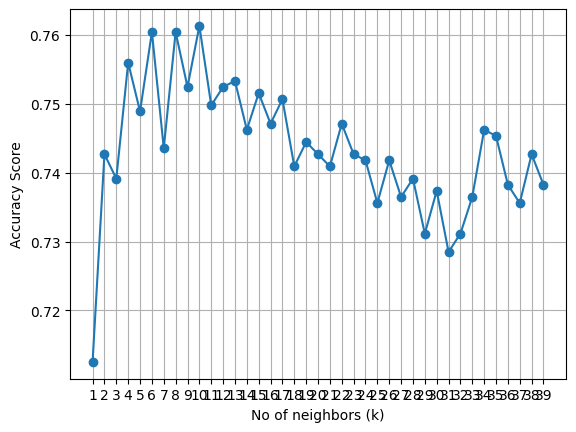

In [182]:
plt.plot(neighbors_range, acc_list, 'o-')
plt.xlabel('No of neighbors (k)')
plt.ylabel('Accuracy Score')
plt.xticks(neighbors_range)
plt.grid()

In [183]:
# initializing the model using k value 37
kNN_classifier = KNeighborsClassifier(n_neighbors = 10, metric = 'euclidean')

#training the ML model
kNN_classifier.fit(X_train, y_train)
#predicting using trained ML model
y_pred_knn_ecldn = kNN_classifier.predict(X_test)
#evaluating the ML model

acc_knn_ecldn = accuracy_score(y_test,y_pred_knn_ecldn)
prec_knn_ecldn = precision_score(y_test,y_pred_knn_ecldn)
f1_knn_ecldn = f1_score(y_test,y_pred_knn_ecldn)
rec_knn_ecldn = recall_score(y_test,y_pred_knn_ecldn)

print('Accuracy of k-NN model is:',acc_knn_ecldn)
print('Precision of NN model is:',prec_knn_ecldn)
print('f1 Score of NN model is:',f1_knn_ecldn)
print('Recall of NN model is:',rec_knn_ecldn)
confusion_matrix(y_test,y_pred_knn_ecldn)


Accuracy of k-NN model is: 0.7613132209405501
Precision of NN model is: 0.6368159203980099
f1 Score of NN model is: 0.4876190476190476
Recall of NN model is: 0.3950617283950617


array([[730,  73],
       [196, 128]])

# Naive Baye's Model

In [186]:
# initializing the model
naive_bayes = GaussianNB()

# training the model
naive_bayes.fit(X_train,y_train)

# predict the model using training data
y_pred_nb = naive_bayes.predict(X_test)

# evaluate the model
acc_nb = accuracy_score(y_test,y_pred_nb)
prec_nb = precision_score(y_test,y_pred_nb)
f1_nb = f1_score(y_test,y_pred_nb)
rec_nb = recall_score(y_test,y_pred_nb)

In [187]:
print('Accuracy of Naive Bayes model is:',acc_nb)
print('Precision of Naive Bayes model is:',prec_nb)
print('f1 Score of Naive Bayes model is:',f1_nb)
print('Recall of Naive Bayes model is:',rec_nb)
confusion_matrix(y_test,y_pred_nb)

Accuracy of Naive Bayes model is: 0.637089618456078
Precision of Naive Bayes model is: 0.4351145038167939
f1 Score of Naive Bayes model is: 0.5822267620020429
Recall of Naive Bayes model is: 0.8796296296296297


array([[433, 370],
       [ 39, 285]])

# Decision Tree Model

In [188]:
# initializing the model
dt_model = DecisionTreeClassifier()

# training the model
dt_model.fit(X_train,y_train) # generalization

# predict the model using training data
y_pred_dt = dt_model.predict(X_test)

# evaluate the model
acc_dt = accuracy_score(y_test,y_pred_dt)
prec_dt = precision_score(y_test,y_pred_dt)
f1_dt = f1_score(y_test,y_pred_dt)
rec_dt = recall_score(y_test,y_pred_dt)

In [189]:
print('Accuracy of Decision Tree model is:',acc_dt)
print('Precision of Decision Tree model is:',prec_dt)
print('f1 Score of Decision Tree model is:',f1_dt)
print('Recall of Decision Tree model is:',rec_dt)
confusion_matrix(y_test,y_pred_dt)

Accuracy of Decision Tree model is: 0.712511091393079
Precision of Decision Tree model is: 0.5
f1 Score of Decision Tree model is: 0.4807692307692308
Recall of Decision Tree model is: 0.46296296296296297


array([[653, 150],
       [174, 150]])

# SVM Model

In [190]:
# defining a support vector machine classifier
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_classifier.fit(X_train, y_train)
y_pred_svm = svm_classifier.predict(X_test)

# evaluate the model
acc_svm=accuracy_score(y_test,y_pred_svm)
prec_svm= precision_score(y_test,y_pred_svm)
rec_svm=recall_score(y_test,y_pred_svm)
f1_svm=f1_score(y_test,y_pred_svm)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [191]:
print('Accuracy:',acc_svm)
print('Precision:',prec_svm)
print('Recall:',rec_svm)
print('F1 Score:',f1_svm)
confusion_matrix(y_test,y_pred_svm)

Accuracy: 0.712511091393079
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


array([[803,   0],
       [324,   0]])

## Comparison of Models


In [192]:
comparison_data = pd.DataFrame({
    'Model': ['Decision Tree','Logistic Regression','Naive Bayes','SVM','KNN'],
    'Accuracy': [acc_dt,acc_log_reg,acc_nb,acc_svm,acc_knn_ecldn],
    'Precision': [prec_dt,prec_log_reg,prec_nb,prec_svm,prec_knn_ecldn],
    'Recall': [rec_dt,rec_log_reg,rec_nb,rec_svm,rec_knn_ecldn],
    'F1 Score': [f1_dt,f1_log_reg,f1_nb,f1_svm,f1_knn_ecldn]
})

comparison_data


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.712511,0.500000,0.462963,0.480769
1,Logistic Regression,0.776398,0.639535,0.509259,0.567010
2,Naive Bayes,0.637090,0.435115,0.879630,0.582227
3,SVM,0.712511,0.000000,0.000000,0.000000
4,KNN,0.761313,0.636816,0.395062,0.487619


Highest accuracy and precision is for logistic regression model

so choosing this model will be apt

# Test data Loading

In [193]:
testing_data_path = '/content/drive/MyDrive/DSA_ICT/Data/Testing_data.csv'
testing_data = pd.read_csv(testing_data_path)

In [194]:
testing_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [196]:
testing_data.shape

(1409, 21)

In [197]:
testing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [198]:
testing_data = testing_data.drop('customerID',axis=1)

In [233]:
testing_data.isnull().sum()

,0
tenure,0
PhoneService,0
Contract,0
MonthlyCharges,0
TotalCharges,2
Customer_Lifetime_Value,0
Tenure_Contract_Interaction,0
MultipleLines_No phone service,0
MultipleLines_Yes,0
InternetService_Fiber optic,0


In [234]:
testing_data['TotalCharges'].fillna(testing_data['TotalCharges'].median(),inplace=True)

/tmp/ipython-input-244189306.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  testing_data['TotalCharges'].fillna(testing_data['TotalCharges'].median(),inplace=True)


In [200]:
testing_data['TotalCharges'] = pd.to_numeric(testing_data['TotalCharges'], errors='coerce')

In [202]:
testing_data.nunique()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3


In [204]:
testing_data['MultipleLines'] = testing_data['MultipleLines'].replace('No phone service','No')
internet_dependent_col = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]
for col in internet_dependent_col:
    testing_data[col] = testing_data[col].replace('No internet service', 'No')
testing_data['StreamingMovies'].value_counts()

,count
StreamingMovies,
No,876
Yes,533


In [205]:
testing_data['Churn'] = testing_data['Churn'].map({'Yes': 1, 'No': 0})

In [206]:
testing_data['Customer_Lifetime_Value'] =testing_data['tenure'] * testing_data['MonthlyCharges']
# Create a numeric mapping for Contract if not already done
# Month-to-month: 1, One year: 12, Two year: 24
testing_data['Contract'] = testing_data['Contract'].map({'Month-to-month': 1, 'One year': 12, 'Two year': 24})

# Interaction Feature
testing_data['Tenure_Contract_Interaction'] = testing_data['tenure'] * testing_data['Contract']

In [207]:
testing_data.drop(columns=['PaperlessBilling'], inplace=True)
testing_data.drop(columns=['gender'], inplace=True)
testing_data.drop(columns=['SeniorCitizen'], inplace=True)
testing_data.drop(columns=['Partner'], inplace=True)
testing_data.drop(columns=['Dependents'], inplace=True)
testing_data.drop(columns=['PaymentMethod'], inplace=True)

In [208]:
leEncoder = LabelEncoder()
testing_data['PhoneService'] = leEncoder.fit_transform(testing_data['PhoneService'])

In [211]:
onehot_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

testing_data = pd.get_dummies(testing_data, columns = onehot_cols, drop_first=True,dtype=int)

In [212]:
minmaxscale_cols= ['tenure','MonthlyCharges','TotalCharges']

scaler = MinMaxScaler()
testing_data[minmaxscale_cols] = scaler.fit_transform(testing_data[minmaxscale_cols])

In [224]:
testing_data.head()

,tenure,PhoneService,Contract,MonthlyCharges,TotalCharges,Churn,Customer_Lifetime_Value,Tenure_Contract_Interaction,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes
0,0.555556,1,1,0.625626,0.383837,0,3248.0,40,1,1,0,0,0,1,0,0,0
1,0.166667,1,12,0.602102,0.100600,0,946.2,144,1,0,0,1,0,1,0,1,1
2,0.597222,1,12,0.813814,0.491625,1,4300.0,516,1,1,0,0,0,0,1,1,1
3,1.000000,1,24,0.995996,1.000000,0,8510.4,1728,1,1,0,1,1,1,1,1,1
4,0.138889,0,1,0.175676,0.041649,0,362.5,10,0,0,0,0,1,0,1,0,0


In [230]:
train_columns = X_train.columns
testing_data = testing_data.reindex(columns=train_columns, fill_value=0)


In [235]:
testing_data.isna().sum()

,0
tenure,0
PhoneService,0
Contract,0
MonthlyCharges,0
TotalCharges,0
Customer_Lifetime_Value,0
Tenure_Contract_Interaction,0
MultipleLines_No phone service,0
MultipleLines_Yes,0
InternetService_Fiber optic,0


In [236]:
y_pred = log_reg_model.predict(testing_data)

In [237]:
pd.DataFrame(y_pred, columns=['Churn_Prediction']).head(20)

,Churn_Prediction
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [238]:
from sklearn.model_selection import GridSearchCV

# # 1. Define the parameter grid
param_grid = {
     'C': [0.001, 0.01, 0.1, 1, 10, 100], # Strength of regularization (smaller = stronger)
     'penalty': ['l1', 'l2'],            # Type of regularization
     'solver': ['liblinear']             # Required for l1 penalty
 }

# # 2. Initialize GridSearchCV
# # We use 'recall' as the scoring metric because catching churners is our priority
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='recall')

# # 3. Fit to your training data
grid_search.fit(X_train, y_train)

# # 4. Identify the best parameters
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print(f"Best Parameters: {best_params}")

Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
